In [100]:
import pandas as pd
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from utils.KrakenData import KrakenData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals
from ggTrader.Utils import *


Walk Forward Optimization

In [101]:
# setup
k = KrakenHistoricalData()
kd = KrakenData()

start_equity = 1000
symbols = ["BTC"]
interval = "4h"
n_trials = 100  # per window
sampler = TPESampler()
optuna.logging.set_verbosity(optuna.logging.WARNING)  # or ERROR / CRITICAL

# Entire time range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Default Indicator Params
params = {'sar_acceleration': 0.02,
          'sar_maximum': 0.2,
          'atr_multiplier': 3,
          'adx_threshold': 0,  # has little affect
          'adx_length': 14,
          'ce_high_length': 22,
          'ce_low_length': 22,
          'atr_length': 14,  # atr multiplier for chandelier exit
          }
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)

df_multi = k.get_ohlcv_df(symbols, interval=interval)
# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

# bench mark, buy and hold
df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close'] / (df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))


                                   close       equity
2025-09-28 12:00:00+00:00  110011.101562  6659.549805
2025-09-28 16:00:00+00:00  110353.203125  6680.258301
2025-09-28 20:00:00+00:00  112127.796875  6787.684570
2025-09-29 00:00:00+00:00  111862.500000  6771.624023
2025-09-29 04:00:00+00:00  111863.601562  6771.690918
2025-09-29 08:00:00+00:00  112093.398438  6785.602051
2025-09-29 12:00:00+00:00  113844.000000  6891.575195
2025-09-29 16:00:00+00:00  114358.296875  6922.708008
2025-09-29 20:00:00+00:00  114365.203125  6923.125977
2025-09-30 00:00:00+00:00  114430.601562  6927.084961


Computed test_size=668, max_train_size=2672


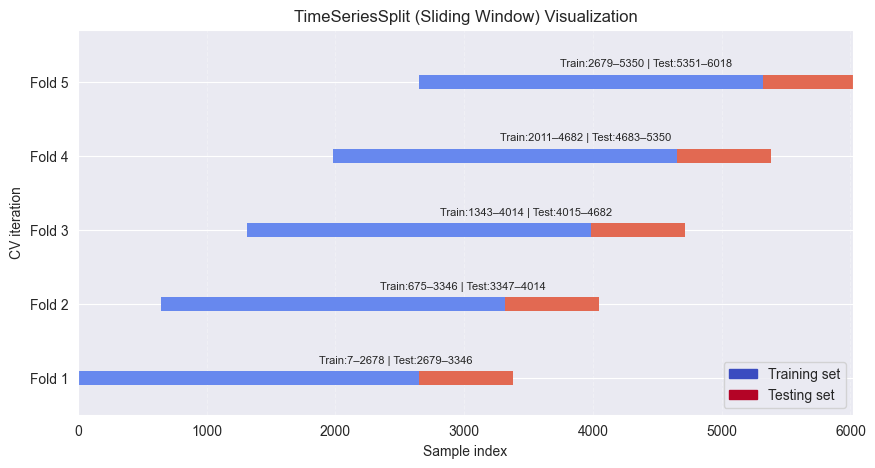

Fold 1: Train [2023-01-02 04:00:00+00:00–2024-03-22 08:00:00+00:00] (445), Test [2024-03-22 12:00:00+00:00–2024-07-11 16:00:00+00:00] (111)
Fold 2: Train [2023-04-23 12:00:00+00:00–2024-07-11 16:00:00+00:00] (445), Test [2024-07-11 20:00:00+00:00–2024-10-31 00:00:00+00:00] (111)
Fold 3: Train [2023-08-12 20:00:00+00:00–2024-10-31 00:00:00+00:00] (445), Test [2024-10-31 04:00:00+00:00–2025-02-19 08:00:00+00:00] (111)
Fold 4: Train [2023-12-02 04:00:00+00:00–2025-02-19 08:00:00+00:00] (445), Test [2025-02-19 12:00:00+00:00–2025-06-10 16:00:00+00:00] (111)
Fold 5: Train [2024-03-22 12:00:00+00:00–2025-06-10 16:00:00+00:00] (445), Test [2025-06-10 20:00:00+00:00–2025-09-30 00:00:00+00:00] (111)


In [102]:
# Train split
n_splits = 5
test_ratio = 0.2
tscv, test_size, max_train_size = make_end_anchored_tscv(n_samples=len(df), n_splits=n_splits, test_ratio=test_ratio)
print(f"Computed test_size={test_size}, max_train_size={max_train_size}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_cv_indices(tscv, df.index, ax, n_splits)
plt.show()

# 4. Print fold ranges
for i, (tr, tt) in enumerate(tscv.split(df.index), 1):
    print(
        f"Fold {i}: Train [{df.index[tr[0]]}–{df.index[tr[-1]]}] ({len(tr) / 6:.0f}), Test [{df.index[tt[0]]}–{df.index[tt[-1]]}] ({len(tt) / 6:.0f})")

Optuna setup

In [103]:
best_params_list = []
sortino_list = []

for i, (tr, tt) in enumerate(tscv.split(df.index), 1):
    df_train = df.iloc[tr]
    df_test = df.iloc[tt]
    print(f"Fold {i}/{n_splits}:")


    def objective(trial):
        params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 3, step=0.1)
        params['ce_low_length'] = trial.suggest_int("ce_low_length", 1, 20)

        s = Signals(**params)
        signals = s.calc_signals(df_train.copy())

        bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee, start_equity=start_equity)
        stats, _ = bt.run()
        return stats['sortino']


    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_params
    best_params_list.append(best_params)

    # backtest best parameters on test set
    params['atr_multiplier'] = best_params['atr_multiplier']
    params['ce_low_length'] = best_params['ce_low_length']

    s1 = Signals(**params)
    signals = s1.calc_signals(df_test.copy())

    bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee, start_equity=start_equity)
    stats, _ = bt.run()
    sortino = stats['sortino']
    sortino_list.append(sortino)

print(f"...Optimization Complete")

Fold 1/5:
Fold 2/5:
Fold 3/5:
Fold 4/5:
Fold 5/5:
...Optimization Complete


In [104]:
print("\nWalk Forward Optimization Results:")
rows = [{**p, "score": float(s), "fold": i + 1} for i, (p, s) in enumerate(zip(best_params_list, sortino_list))]
df_result = pd.DataFrame(rows).set_index("fold")
print(tabulate(df_result, headers="keys", tablefmt="github"))
result_stats = df_result.describe()

print("\nWalk Forward Optimization Stats:")
print(tabulate(result_stats, headers="keys", tablefmt="github"))

avg = df_result.mean(numeric_only=True)  # returns a Series with column averages

params['atr_multiplier'] = round(avg['atr_multiplier'], 1)
params['ce_low_length'] = int(avg['ce_low_length'])



Walk Forward Optimization Results:
|   fold |   atr_multiplier |   ce_low_length |    score |
|--------|------------------|-----------------|----------|
|      1 |              1.1 |               1 |  5.56685 |
|      2 |              1.1 |               1 | 11.6205  |
|      3 |              1.1 |               1 | 13.6878  |
|      4 |              1   |               1 | 13.0587  |
|      5 |              1   |               1 | 10.2269  |

Walk Forward Optimization Stats:
|       |   atr_multiplier |   ce_low_length |    score |
|-------|------------------|-----------------|----------|
| count |        5         |               5 |  5       |
| mean  |        1.06      |               1 | 10.8321  |
| std   |        0.0547723 |               0 |  3.23356 |
| min   |        1         |               1 |  5.56685 |
| 25%   |        1         |               1 | 10.2269  |
| 50%   |        1.1       |               1 | 11.6205  |
| 75%   |        1.1       |               1 | 13.058

Run final backtest with average parameters

In [110]:
print(tabulate(params.items(), headers="keys", tablefmt="github"))

s_final = Signals(**params)

signals = s_final.calc_signals(df.copy())

bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee, start_equity=start_equity)
stats, profit_df = bt.run()

print(f"\nFinal Backtest Stats:")
print(tabulate(stats.items(), headers="keys", tablefmt="github"))
ts = pd.Timestamp.utcnow()
row = {"symbol": symbols[0],'timestamp':ts, **params, **stats,}  # later keys overwrite earlier if duplicates
df_stats = pd.DataFrame([row])
df_stats = df_stats.set_index("symbol")
print(df_stats)


| 0                |     1 |
|------------------|-------|
| sar_acceleration |  0.02 |
| sar_maximum      |  0.2  |
| atr_multiplier   |  1.1  |
| adx_threshold    |  0    |
| adx_length       | 14    |
| ce_high_length   | 22    |
| ce_low_length    |  1    |
| atr_length       | 14    |

Final Backtest Stats:
| 0                |            1 |
|------------------|--------------|
| trading_days     |   1003       |
| total_profit     | 123096       |
| total_profit_pct |  12309.6     |
| sharpe           |      6.31709 |
| sortino          |     12.7734  |
| wins             |    216       |
| losses           |     24       |
| win_rate         |     90       |
                              timestamp  sar_acceleration  sar_maximum  \
symbol                                                                   
BTC    2025-11-08 02:35:50.134138+00:00              0.02          0.2   

        atr_multiplier  adx_threshold  adx_length  ce_high_length  \
symbol                             

In [112]:
# Python
from pathlib import Path
import pandas as pd

def load_or_create_csv(path, columns=None):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p,index_col=0)
    # create empty DataFrame with optional columns
    return pd.DataFrame(columns=columns or [])

filename = "optimization_results.csv"
df_stats_csv = load_or_create_csv(filename)
print(df_stats_csv)
df_stats_csv  = pd.concat([df_stats_csv, df_stats], ignore_index=False)
print(df_stats_csv)
df_stats_csv.to_csv(filename)

Empty DataFrame
Columns: []
Index: []
                              timestamp  sar_acceleration  sar_maximum  \
symbol                                                                   
BTC    2025-11-08 02:35:50.134138+00:00              0.02          0.2   

        atr_multiplier  adx_threshold  adx_length  ce_high_length  \
symbol                                                              
BTC                1.1              0          14              22   

        ce_low_length  atr_length  trading_days   total_profit  \
symbol                                                           
BTC                 1          14          1003  123096.429383   

        total_profit_pct    sharpe    sortino  wins  losses  win_rate  
symbol                                                                 
BTC         12309.642938  6.317091  12.773356   216      24      90.0  


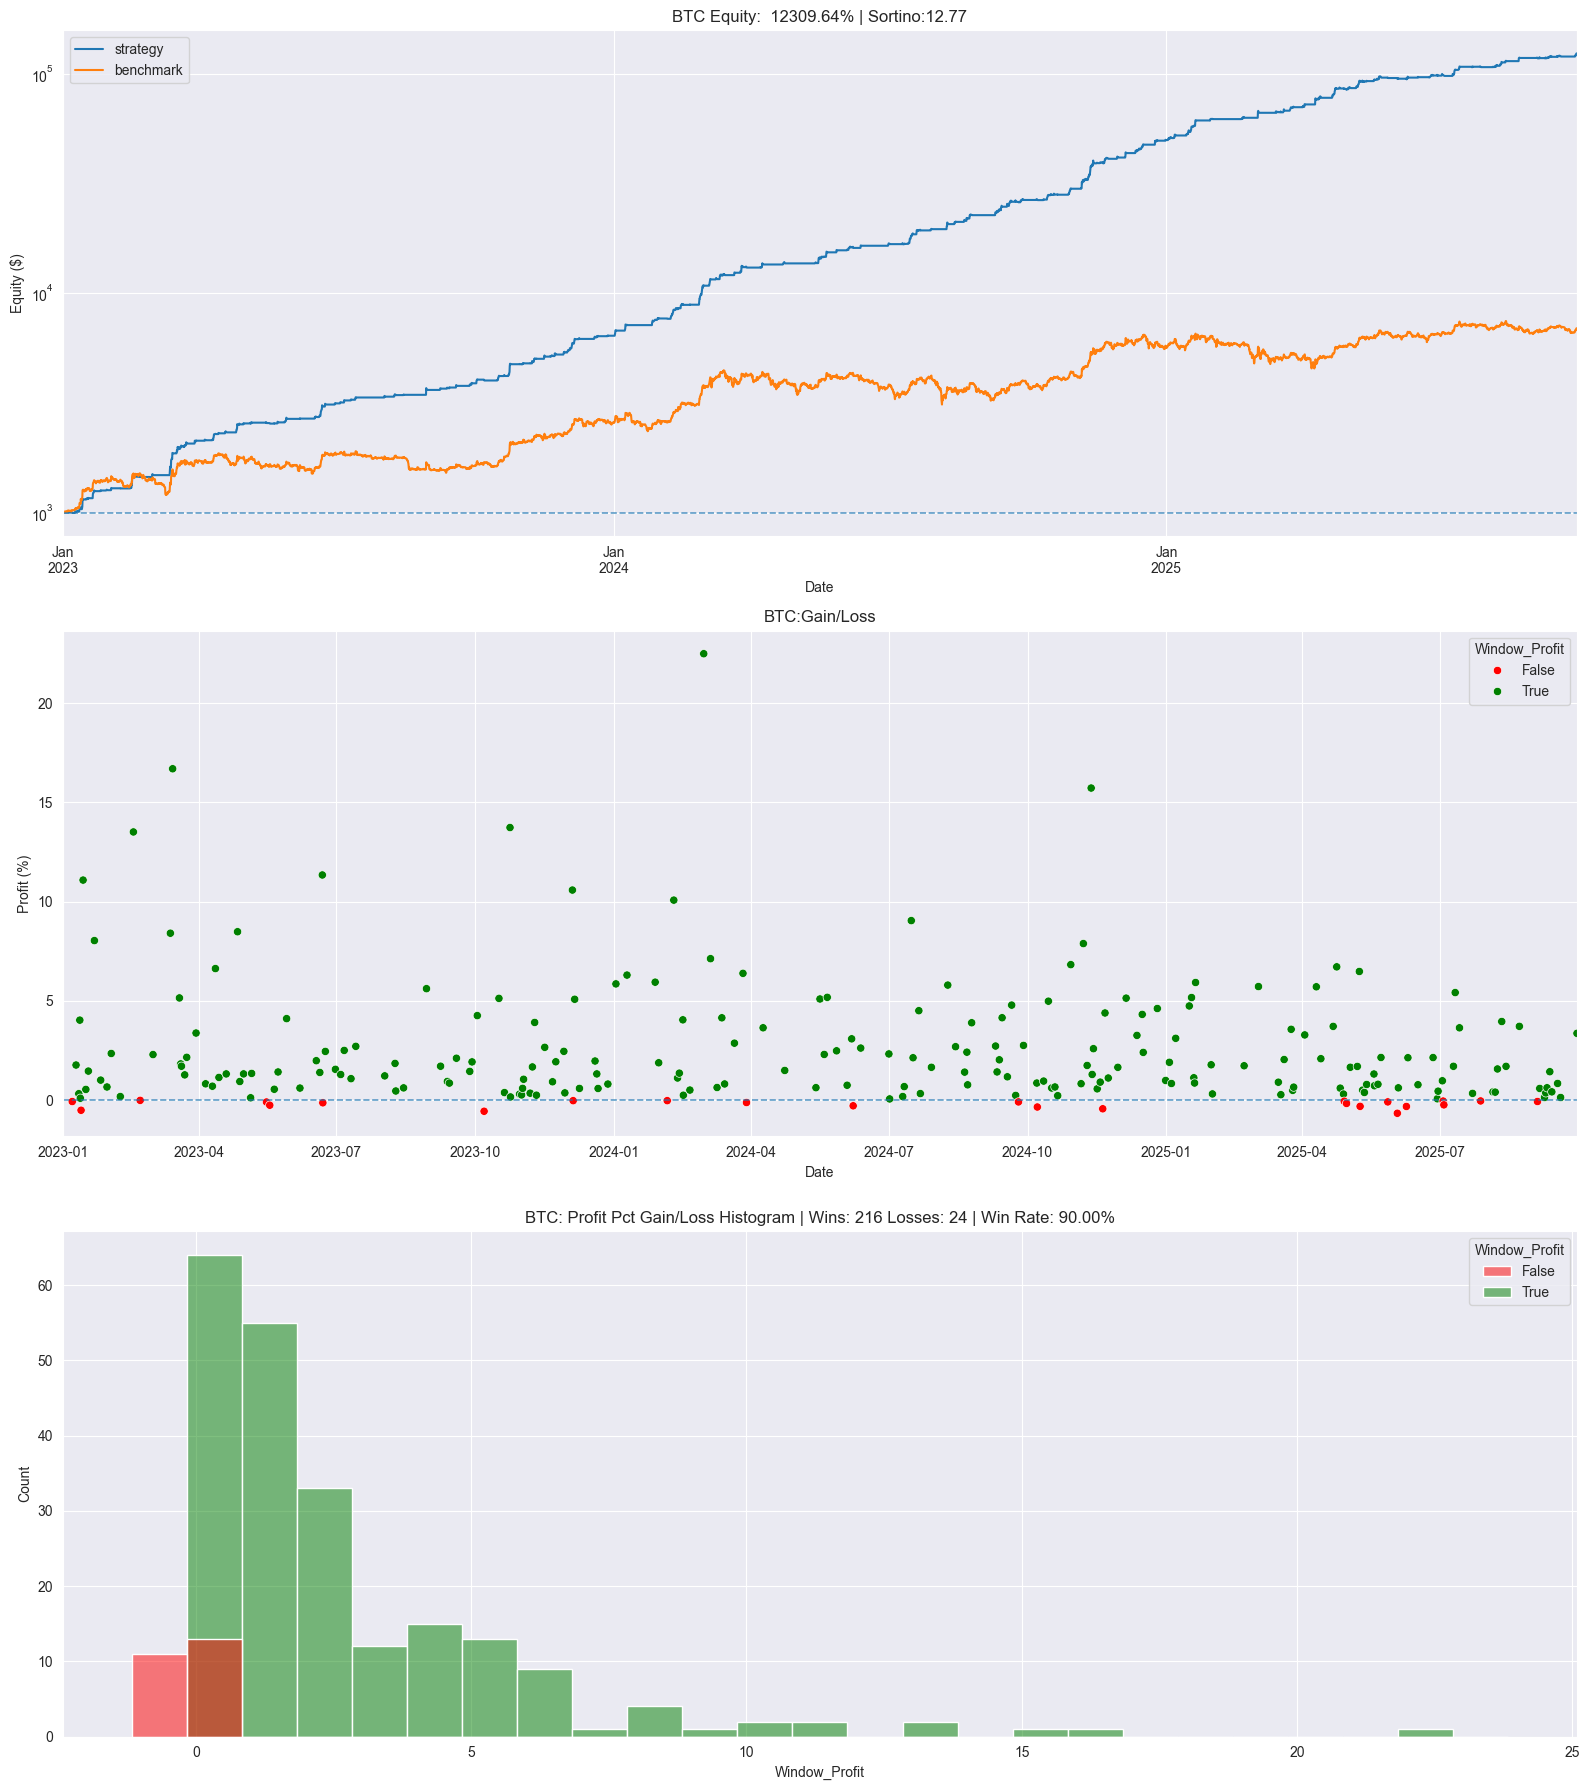

In [107]:
# plots
win_profit = profit_df['Window_Profit'] * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

#Equity Plot
profit_df['Equity'].plot(ax=axes[0],
                         title=f'{symbols[0]} Equity:  {stats["total_profit_pct"]:.2f}% | Sortino:{stats['sortino']:.2f}',
                         label='strategy')
df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].set_xlabel('Date')
axes[0].set_yscale('log')
axes[0].legend()
# axes[0].grid(alpha=0.3, linestyle="--")

axes[0].set_xlim(start, end)
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].minorticks_on()

#Gain/Loss Plot
sns.scatterplot(x=profit_df.index, y=win_profit, ax=axes[1], hue=win_profit > 0, palette={True: 'green', False: 'red'})
axes[1].set_title(f'{symbols[0]}:Gain/Loss')
axes[1].set_ylabel('Profit (%)')
axes[1].set_xlabel('Date')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].set_xlim(start, end)
axes[1].minorticks_on()
plt.tight_layout()

# Histogram Gain/Loss
sns.histplot(profit_df,
             x=win_profit,
             hue=win_profit > 0,
             discrete=True,
             palette={True: 'green', False: 'red'},
             ax=axes[2]
             )
axes[2].set_title(
    f"{symbols[0]}: Profit Pct Gain/Loss Histogram | Wins: {stats['wins']} Losses: {stats['losses']} | Win Rate: {stats['win_rate']:.2f}%")
axes[2].minorticks_on()
plt.tight_layout()
plt.show()

Test on latest result for the last 3 months

In [108]:
days = 3*30
samples = days
latest_df = kd.fetch_ohlcv_df(kd.kraken, symbols[0], timeframe='4h', limit=700)

latest_signals = s_final.calc_signals(latest_df.copy())

bt = Backtest(latest_signals, interval=interval, transaction_fee=transaction_fee, start_equity=start_equity)
latest_stats, latest_profit_df = bt.run()

print(f"\nFinal Backtest Stats:")
print(tabulate(latest_stats.items(), headers="keys", tablefmt="github"))

latest_df_bench_mark = pd.DataFrame()
latest_df_bench_mark['close'] = latest_df['close'].copy()
latest_df_bench_mark['equity'] = start_equity * latest_df_bench_mark['close'] / (latest_df_bench_mark['close'].iloc[0])


end = latest_profit_df.index[-1]
start = latest_profit_df.index[0]


Final Backtest Stats:
| 0                |         1 |
|------------------|-----------|
| trading_days     | 116       |
| total_profit     | 288.274   |
| total_profit_pct |  28.8274  |
| sharpe           |   4.0041  |
| sortino          |   6.57725 |
| wins             |  23       |
| losses           |   2       |
| win_rate         |  92       |


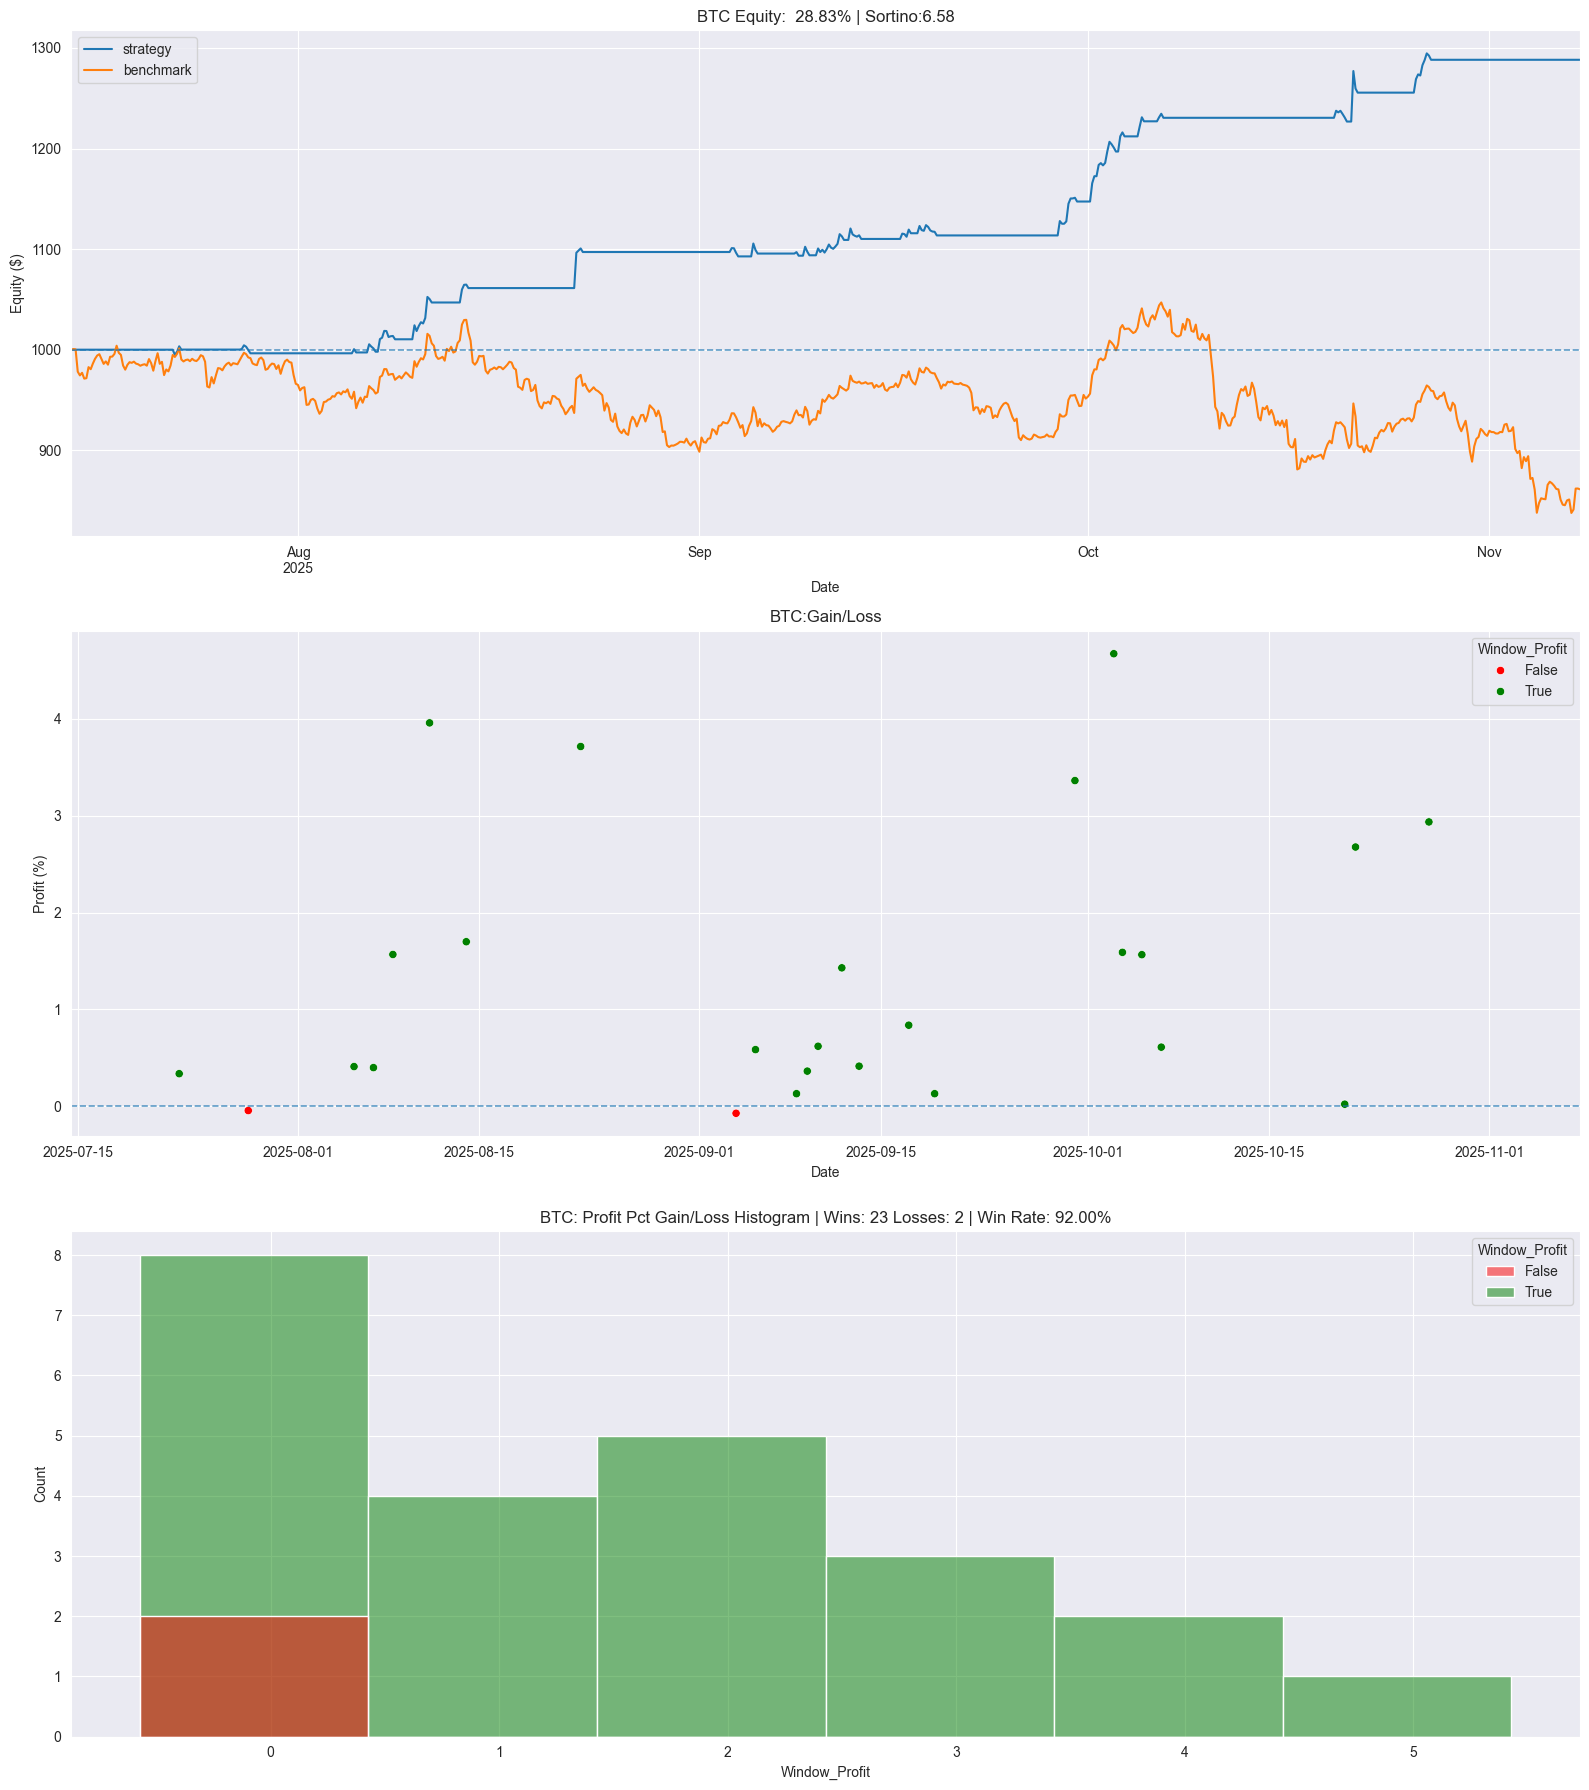

In [109]:
# plots
win_profit = latest_profit_df['Window_Profit'] * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

#Equity Plot
latest_profit_df['Equity'].plot(ax=axes[0],
                         title=f'{symbols[0]} Equity:  {latest_stats["total_profit_pct"]:.2f}% | Sortino:{latest_stats['sortino']:.2f}',
                         label='strategy')
latest_df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].set_xlabel('Date')
# axes[0].set_yscale('log')
axes[0].legend()
# axes[0].grid(alpha=0.3, linestyle="--")

axes[0].set_xlim(start, end)
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].minorticks_on()

#Gain/Loss Plot
sns.scatterplot(x=latest_profit_df.index, y=win_profit, ax=axes[1], hue=win_profit > 0, palette={True: 'green', False: 'red'})
axes[1].set_title(f'{symbols[0]}:Gain/Loss')
axes[1].set_ylabel('Profit (%)')
axes[1].set_xlabel('Date')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].set_xlim(start, end)
axes[1].minorticks_on()
plt.tight_layout()

# Histogram Gain/Loss
sns.histplot(latest_profit_df,
             x=win_profit,
             hue=win_profit > 0,
             discrete=True,
             palette={True: 'green', False: 'red'},
             ax=axes[2]
             )
axes[2].set_title(
    f"{symbols[0]}: Profit Pct Gain/Loss Histogram | Wins: {latest_stats['wins']} Losses: {latest_stats['losses']} | Win Rate: {latest_stats['win_rate']:.2f}%")
axes[2].minorticks_on()
plt.tight_layout()
plt.show()